----- FIRST 5 ROWS OF DATA -----
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Target names: ['setosa' 'versicolor' 'virginica']

Training samples: 120
Testing samples : 30

Model training complete!

----- MODEL EVALUATION -----
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        1

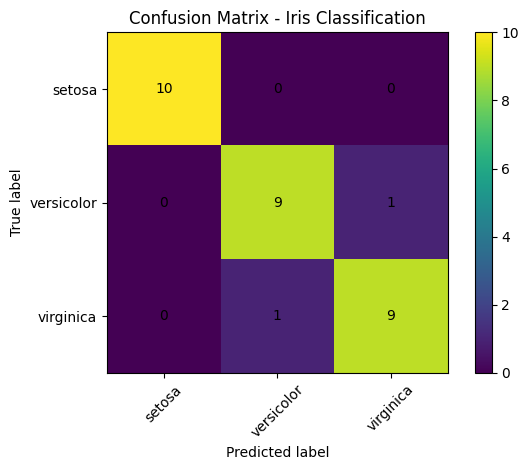


----- SINGLE PREDICTION -----
Input features: [[5.1 3.5 1.4 0.2]]
Predicted class index: 0
Predicted class name : setosa

Model & scaler saved as 'iris_model.pkl' and 'iris_scaler.pkl'
Project successfully completed!


In [ ]:
# iris_classification_project.py
# Easy Machine Learning Project: Iris Flower Classification

# ===============================
# 1. Libraries import
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ===============================
# 2. Dataset load karo
# ===============================
iris = load_iris()

# Features (X) and target (y)
X = iris.data          # 4 columns: sepal length, sepal width, petal length, petal width
y = iris.target        # 0, 1, 2 (teen classes)

# Feature names aur target names ko DataFrame me daal dete hain
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y

print("----- FIRST 5 ROWS OF DATA -----")
print(df.head())
print("\nTarget names:", iris.target_names)

# ===============================
# 3. Train-Test Split
# ===============================
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

# ===============================
# 4. Feature Scaling (Optional but good)
# ===============================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===============================
# 5. Model Selection & Training
# ===============================
# Yaha ek simple model: Logistic Regression
model = LogisticRegression(max_iter=200)
model.fit(X_train_scaled, y_train)

print("\nModel training complete!")

# ===============================
# 6. Evaluation on Test Data
# ===============================
y_pred = model.predict(X_test_scaled)

acc = accuracy_score(y_test, y_pred)
print("\n----- MODEL EVALUATION -----")
print("Accuracy:", acc)
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix print
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# ===============================
# 7. Confusion Matrix Plot
# ===============================
plt.figure()
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix - Iris Classification")
plt.colorbar()
tick_marks = np.arange(len(iris.target_names))
plt.xticks(tick_marks, iris.target_names, rotation=45)
plt.yticks(tick_marks, iris.target_names)
plt.xlabel('Predicted label')
plt.ylabel('True label')

# Har cell ke andar value likhna
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 verticalalignment="center",
                 fontsize=10)

plt.tight_layout()
plt.show()

# ===============================
# 8. Single Prediction Example
# ===============================
# Example flower: [sepal length, sepal width, petal length, petal width]
# Units: cm
sample_flower = np.array([[5.1, 3.5, 1.4, 0.2]])  # ye almost Setosa jaisa hai
sample_flower_scaled = scaler.transform(sample_flower)

pred_class = model.predict(sample_flower_scaled)[0]
pred_name = iris.target_names[pred_class]

print("\n----- SINGLE PREDICTION -----")
print("Input features:", sample_flower)
print("Predicted class index:", pred_class)
print("Predicted class name :", pred_name)

# ===============================
# 9. Model & Scaler Save karna (optional)
# ===============================
import joblib

joblib.dump(model, "iris_model.pkl")
joblib.dump(scaler, "iris_scaler.pkl")

print("\nModel & scaler saved as 'iris_model.pkl' and 'iris_scaler.pkl'")
print("Project successfully completed!")